In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [5]:
# Load dataset
train_df = pd.read_csv("public_data/train.csv")

# Preview dataset
train_df.head()

,CustomerID,UserGender,UserAge,YoungAdultFlag,RetireeStatus,Married,Dependents,NumberofDependents,Country,State,LocationCity,AreaCode,Latitude,Longitude,Population,ReferredaFriend,NumberofReferrals,TenureinMonths,Offer,VoiceService,AvgMonthlyLongDistanceCharges,AdditionalLines,ConnectivityType,InternetType,DataUsageAvg,CyberSecuritySvc,CloudStorageSvc,HardwareInsurance,PrioritySupport,VideoSvc_A,VideoSvc_B,AudioSvc,UnlimitedData,Contract,DigitalInvoicing,TransactionMode,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,CustomerLifetimeValue,ChurnStatus,Month
0,1610a102a7854c5d,Male,71,No,Yes,Yes,Yes,1,United States,California,Pine Valley,91962,32.800671,-116.483363,1604,Yes,9,38,NaN,Yes,28.30,Yes,Yes,Fiber Optic,27,No,Yes,No,No,Yes,Yes,No,Yes,One Year,No,Bank Withdrawal,101.15,3741.85,0.0,0,1075.40,4817.25,4036,No,25-Jan
1,7b4b47a335af4741,Male,77,No,Yes,Yes,No,0,United States,California,Cabazon,92230,33.929812,-116.760580,2355,Yes,5,27,NaN,Yes,33.57,Yes,Yes,DSL,21,No,Yes,Yes,Yes,Yes,Yes,No,Yes,One Year,Yes,Bank Withdrawal,84.80,2309.55,0.0,0,906.39,3215.94,5352,No,25-Jan
2,81465cd8c020404b,Male,78,No,Yes,Yes,No,0,United States,California,Desert Center,92239,33.889605,-115.257009,964,Yes,7,33,NaN,Yes,25.15,Yes,Yes,Fiber Optic,20,Yes,No,Yes,Yes,Yes,Yes,No,Yes,One Year,Yes,Bank Withdrawal,109.90,3694.70,0.0,0,829.95,4524.65,5655,No,25-Jan
3,8fb085ca69574c4c,Male,74,No,Yes,No,No,0,United States,California,Desert Hot Springs,92241,33.832799,-116.250973,5529,No,0,33,Offer C,No,0.00,No,Yes,Cable,11,No,No,Yes,Yes,Yes,Yes,No,Yes,One Year,Yes,Bank Withdrawal,54.60,1803.70,0.0,0,0.00,1803.70,5322,No,25-Jan
4,d2ca70e00e1d419f,Male,71,No,Yes,Yes,Yes,1,United States,California,Morongo Valley,92256,34.097863,-116.594561,3499,Yes,9,32,Offer C,Yes,31.86,No,Yes,Fiber Optic,23,No,Yes,No,No,Yes,Yes,Yes,Yes,One Year,Yes,Mailed Check,93.95,2861.45,0.0,0,1019.52,3880.97,2844,No,25-Jan


In [7]:
# Dataset shape
print("Train dataset shape:", train_df.shape)

# Column data types and null counts
train_df.info()

# Summary statistics for numerical columns
train_df.describe().T

Train dataset shape: (70430, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70430 entries, 0 to 70429
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     70430 non-null  object 
 1   UserGender                     70430 non-null  object 
 2   UserAge                        70430 non-null  int64  
 3   YoungAdultFlag                 70430 non-null  object 
 4   RetireeStatus                  70430 non-null  object 
 5   Married                        70430 non-null  object 
 6   Dependents                     70430 non-null  object 
 7   NumberofDependents             70430 non-null  int64  
 8   Country                        70430 non-null  object 
 9   State                          70430 non-null  object 
 10  LocationCity                   70430 non-null  object 
 11  AreaCode                       70430 non-null  int64  
 12  Latitude     

,count,mean,std,min,25%,50%,75%,max
UserAge,70430.0,46.062417,14.003273,19.000000,35.000000,46.000000,56.000000,80.000000
NumberofDependents,70430.0,0.297955,0.678412,0.000000,0.000000,0.000000,0.000000,9.000000
AreaCode,70430.0,93490.050220,1810.046941,90001.000000,92099.000000,93474.000000,95321.000000,96150.000000
Latitude,70430.0,36.174811,2.424407,32.555828,33.974383,35.944662,38.162694,41.962127
Longitude,70430.0,-119.730571,2.097917,-124.301372,-121.693180,-119.512403,-117.959131,-114.192901
Population,70430.0,22071.588215,21174.357978,11.000000,2204.250000,17345.500000,36149.000000,105285.000000
NumberofReferrals,70430.0,1.646741,2.458235,0.000000,0.000000,0.000000,3.000000,11.000000
TenureinMonths,70430.0,31.459279,23.807754,1.000000,8.000000,28.000000,54.000000,72.000000
AvgMonthlyLongDistanceCharges,70430.0,26.351392,16.855679,0.000000,12.611495,25.369840,38.189507,74.970000
DataUsageAvg,70430.0,20.284964,17.485892,0.000000,7.000000,17.000000,27.000000,85.000000


In [9]:
# Missing values by column
missing = train_df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Offer               48221
InternetType        17018
PrioritySupport     12383
DigitalInvoicing    12173
dtype: int64

In [11]:
# Identify numerical, categorical, and temporal features
numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

# If any temporal columns exist, you can parse them later
temporal_features = ['Month']  # From metadata, Month seems temporal

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Temporal Features:", temporal_features)

Numerical Features: ['UserAge', 'NumberofDependents', 'AreaCode', 'Latitude', 'Longitude', 'Population', 'NumberofReferrals', 'TenureinMonths', 'AvgMonthlyLongDistanceCharges', 'DataUsageAvg', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue', 'CustomerLifetimeValue']
Categorical Features: ['CustomerID', 'UserGender', 'YoungAdultFlag', 'RetireeStatus', 'Married', 'Dependents', 'Country', 'State', 'LocationCity', 'ReferredaFriend', 'Offer', 'VoiceService', 'AdditionalLines', 'ConnectivityType', 'InternetType', 'CyberSecuritySvc', 'CloudStorageSvc', 'HardwareInsurance', 'PrioritySupport', 'VideoSvc_A', 'VideoSvc_B', 'AudioSvc', 'UnlimitedData', 'Contract', 'DigitalInvoicing', 'TransactionMode', 'ChurnStatus', 'Month']
Temporal Features: ['Month']


In [13]:
# Show top 5 unique values for each categorical column
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(train_df[col].value_counts().head())


Column: CustomerID
CustomerID
8.57E+15            2
1610a102a7854c5d    1
a0366a6a76a4403e    1
734aef4722934160    1
d9c10f13b5194d67    1
Name: count, dtype: int64

Column: UserGender
UserGender
Male      36111
Female    34319
Name: count, dtype: int64

Column: YoungAdultFlag
YoungAdultFlag
No     65525
Yes     4905
Name: count, dtype: int64

Column: RetireeStatus
RetireeStatus
No     66293
Yes     4137
Name: count, dtype: int64

Column: Married
Married
No     37935
Yes    32495
Name: count, dtype: int64

Column: Dependents
Dependents
No     61740
Yes     8690
Name: count, dtype: int64

Column: Country
Country
United States    70430
Name: count, dtype: int64

Column: State
State
California    70430
Name: count, dtype: int64

Column: LocationCity
LocationCity
San Diego        2871
Los Angeles      2177
SD               1161
San Francisco    1160
San Jose         1001
Name: count, dtype: int64

Column: ReferredaFriend
ReferredaFriend
No     40802
Yes    29628
Name: count, dtype: int64

<Figure size 1500x1000 with 0 Axes>

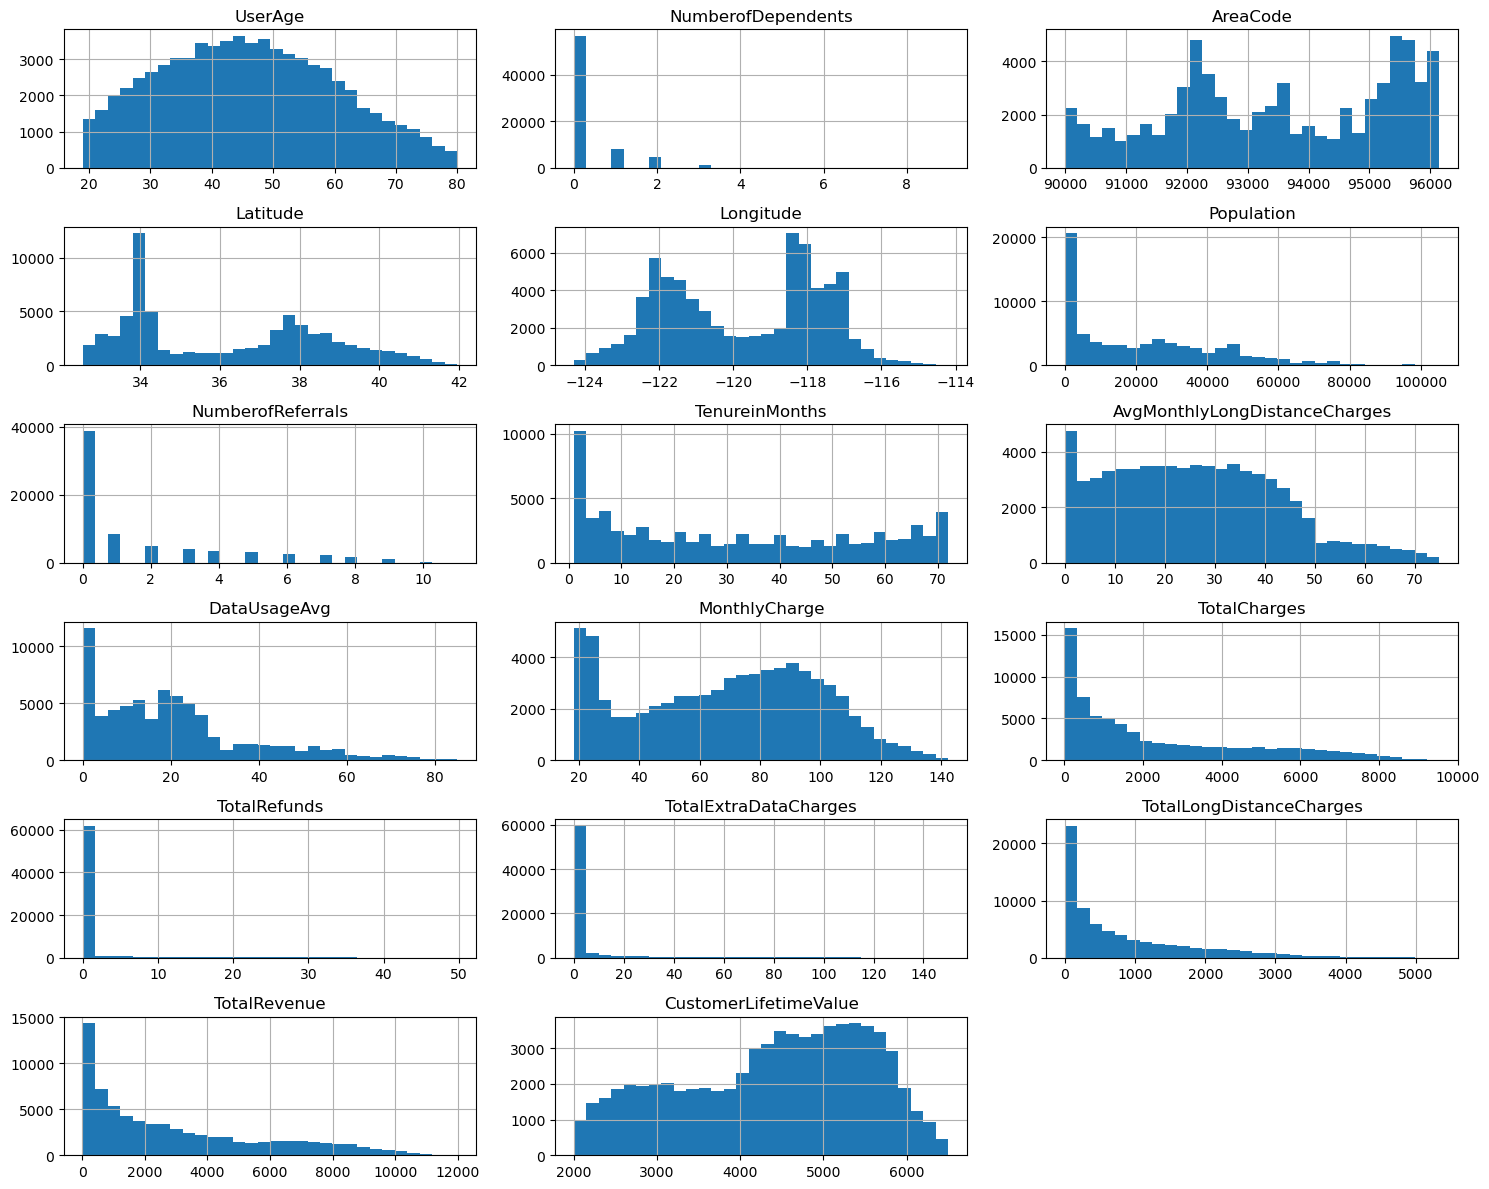

In [15]:
# Histograms for numerical features
plt.figure(figsize=(15, 10))
train_df[numerical_features].hist(bins=30, figsize=(15,12), layout=(len(numerical_features)//3 + 1, 3))
plt.tight_layout()
plt.show()

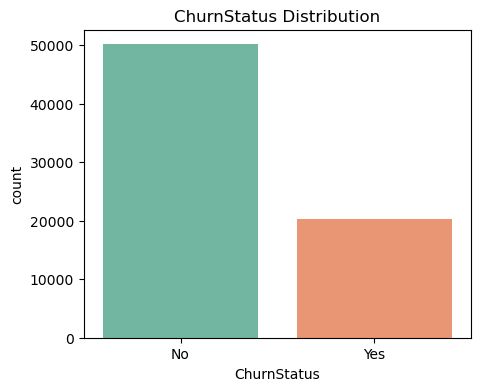

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(data=train_df, x='ChurnStatus', palette='Set2')
plt.title("ChurnStatus Distribution")
plt.show()

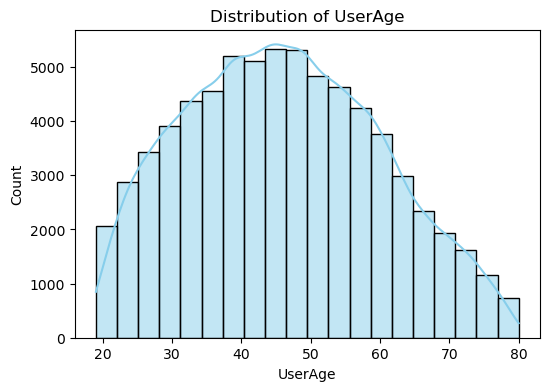

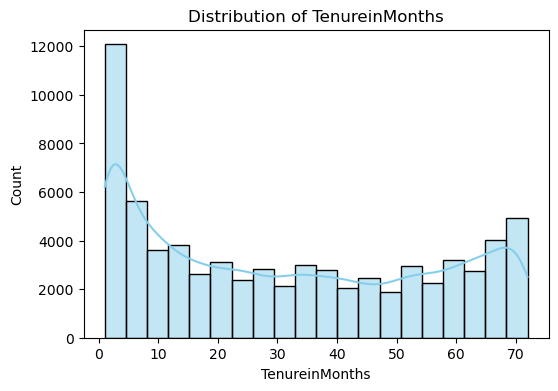

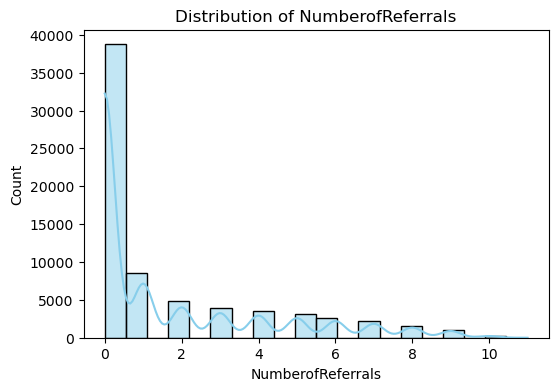

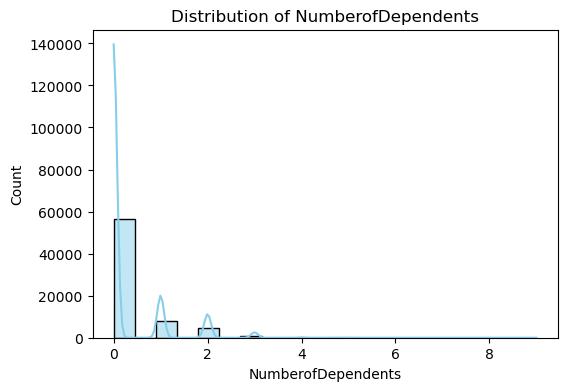

In [19]:
for col in ['UserAge', 'TenureinMonths', 'NumberofReferrals', 'NumberofDependents']:
    plt.figure(figsize=(6,4))
    sns.histplot(train_df[col], kde=True, color='skyblue', bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()


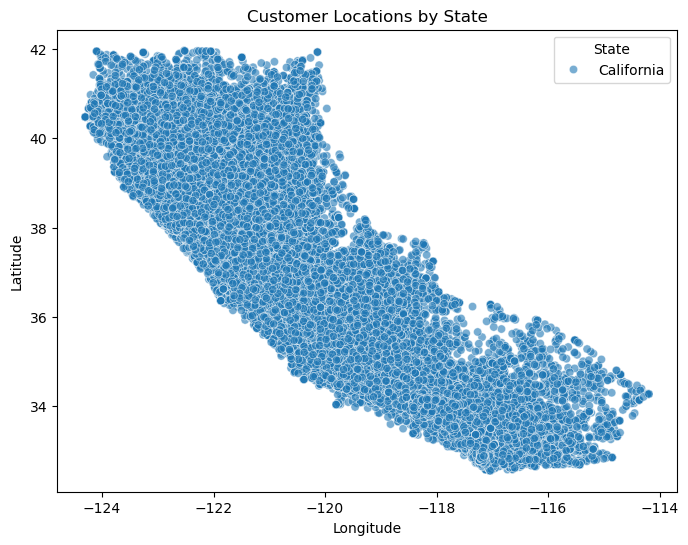

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=train_df, x='Longitude', y='Latitude', hue='State', palette='tab20', alpha=0.6)
plt.title("Customer Locations by State")
plt.show()

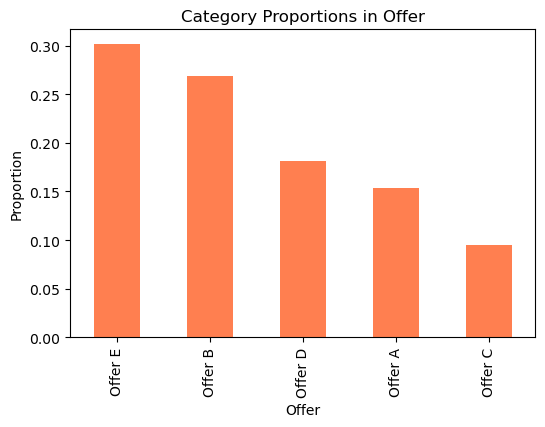

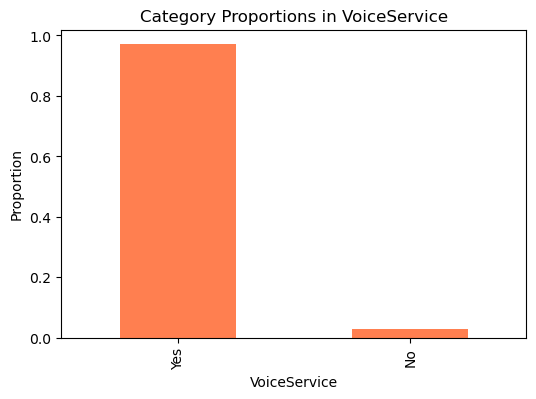

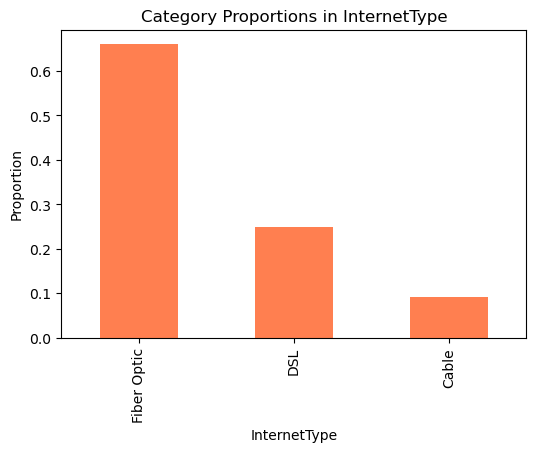

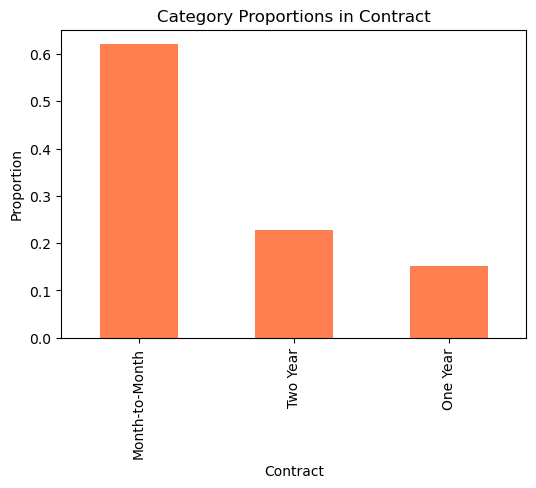

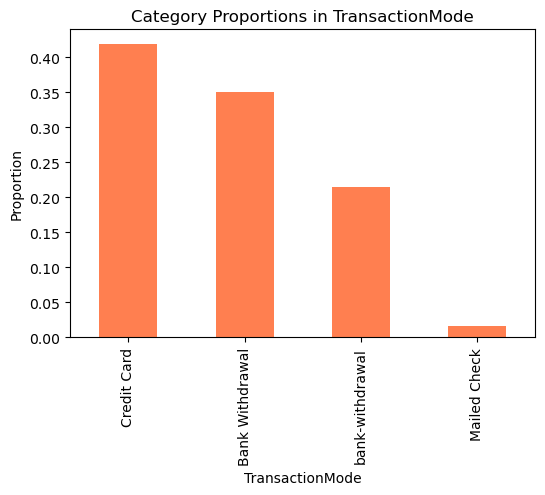

In [23]:
cat_cols = ['Offer', 'VoiceService', 'InternetType', 'Contract', 'TransactionMode']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    (train_df[col].value_counts(normalize=True)
        .plot(kind='bar', color='coral'))
    plt.title(f"Category Proportions in {col}")
    plt.ylabel("Proportion")
    plt.show()


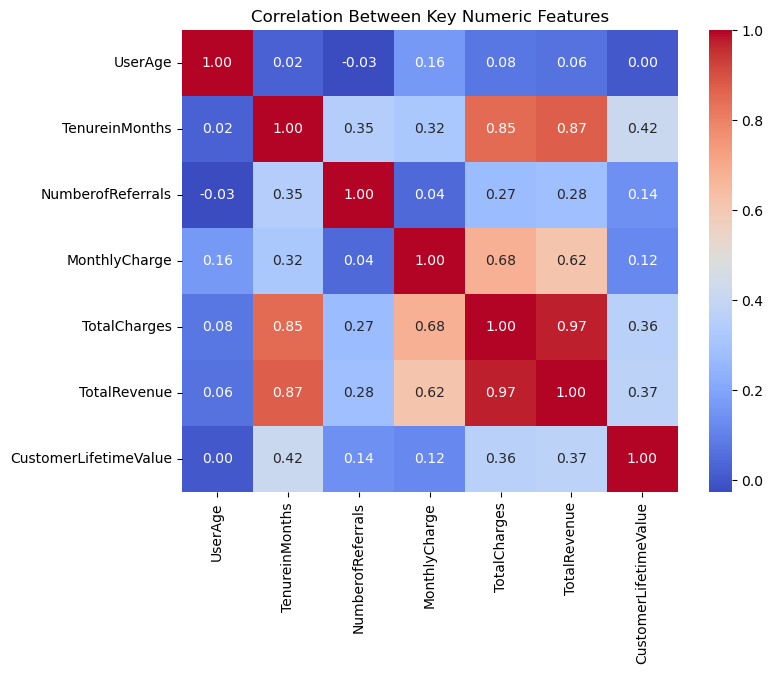

In [25]:
corr_cols = ['UserAge','TenureinMonths','NumberofReferrals','MonthlyCharge','TotalCharges','TotalRevenue','CustomerLifetimeValue']
plt.figure(figsize=(8,6))
sns.heatmap(train_df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Between Key Numeric Features")
plt.show()


In [27]:
# Convert Month to datetime (assume format like '25-Jan')
train_df['Month'] = pd.to_datetime(train_df['Month'], format='%d-%b', errors='coerce')

# Quick check
train_df[['Month']].head()


,Month
0,1900-01-25
1,1900-01-25
2,1900-01-25
3,1900-01-25
4,1900-01-25


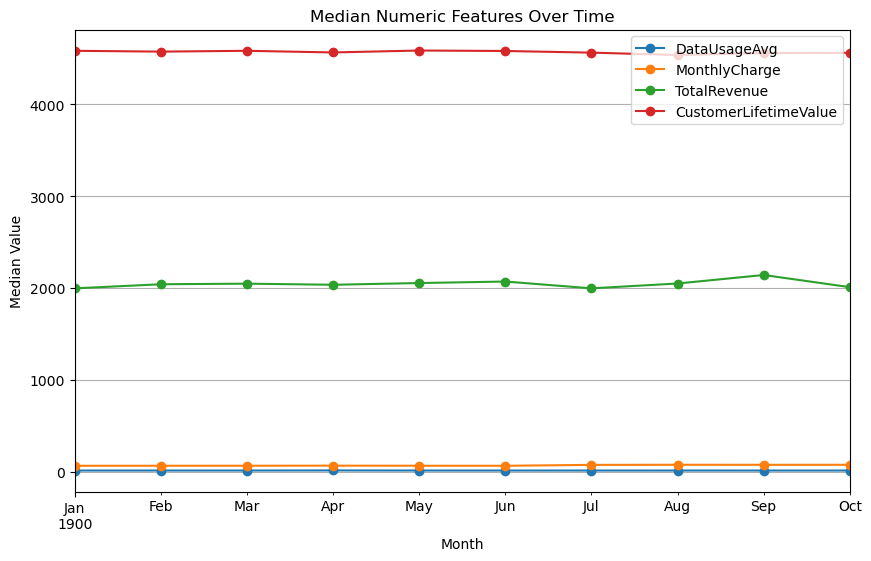

In [29]:
num_cols = ['DataUsageAvg', 'MonthlyCharge', 'TotalRevenue', 'CustomerLifetimeValue']

plt.figure(figsize=(10,6))
for col in num_cols:
    monthly_median = train_df.groupby(train_df['Month'].dt.to_period('M'))[col].median()
    monthly_median.plot(marker='o', label=col)

plt.title("Median Numeric Features Over Time")
plt.ylabel("Median Value")
plt.xlabel("Month")
plt.grid(True)
plt.legend()
plt.show()


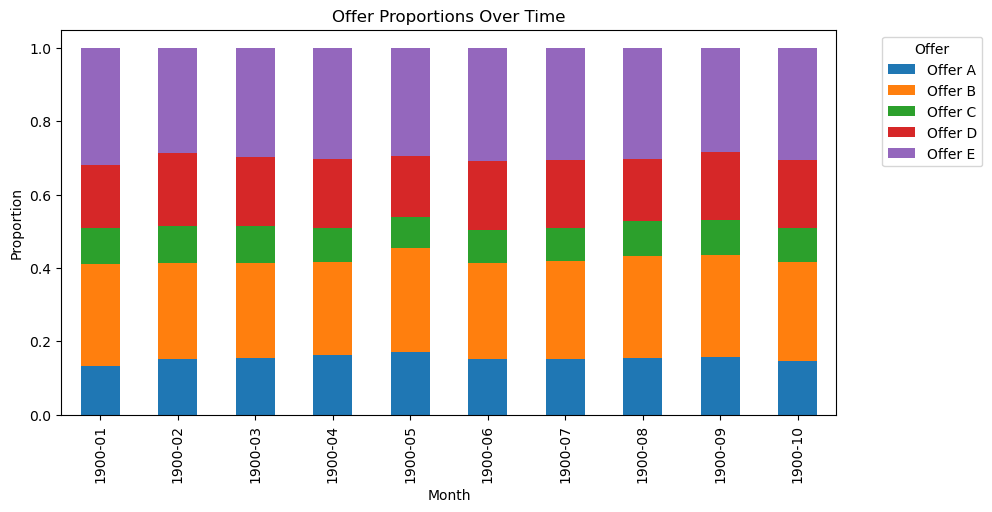

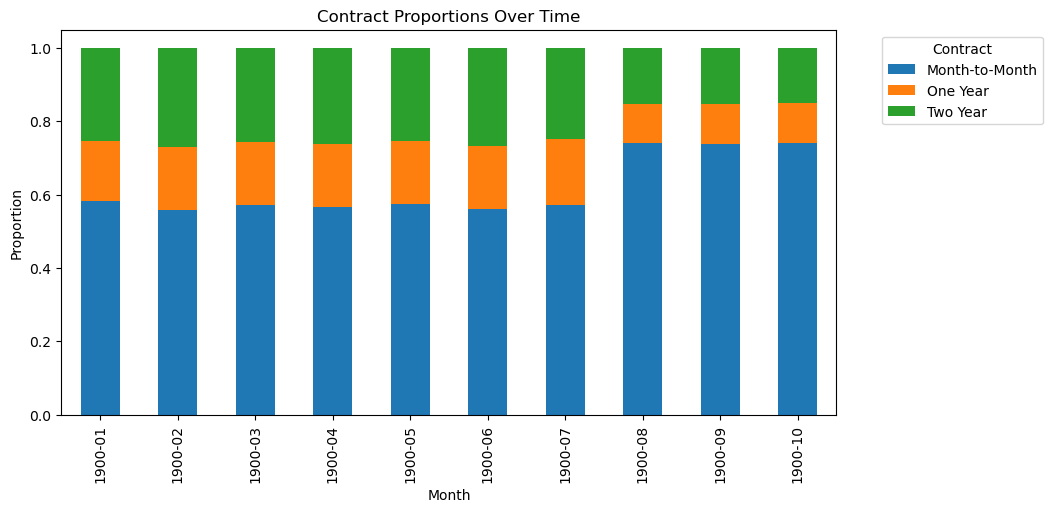

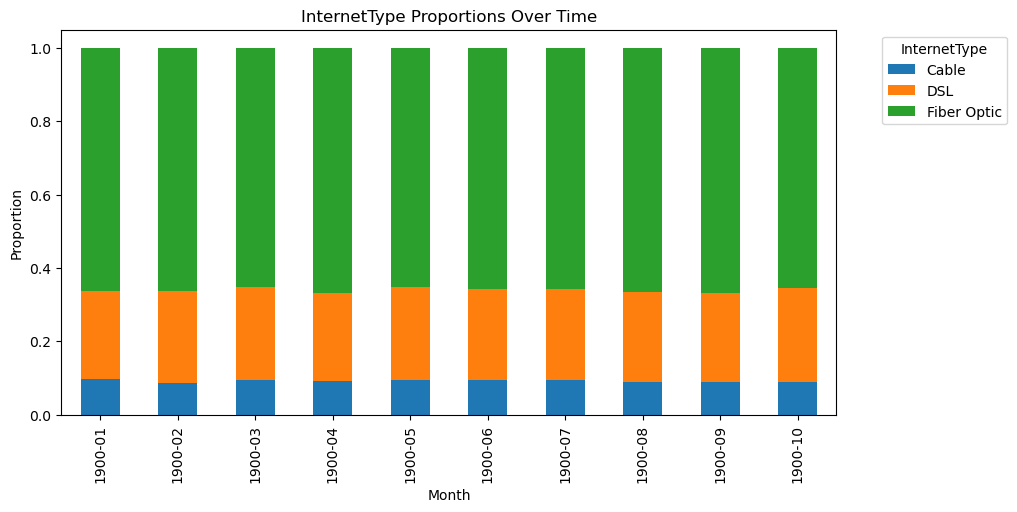

In [31]:
cat_cols = ['Offer', 'Contract', 'InternetType']

for col in cat_cols:
    prop_df = train_df.groupby(train_df['Month'].dt.to_period('M'))[col].value_counts(normalize=True).unstack()
    prop_df.plot(kind='bar', stacked=True, figsize=(10,5))
    plt.title(f"{col} Proportions Over Time")
    plt.ylabel("Proportion")
    plt.xlabel("Month")
    plt.legend(title=col, bbox_to_anchor=(1.05, 1))
    plt.show()


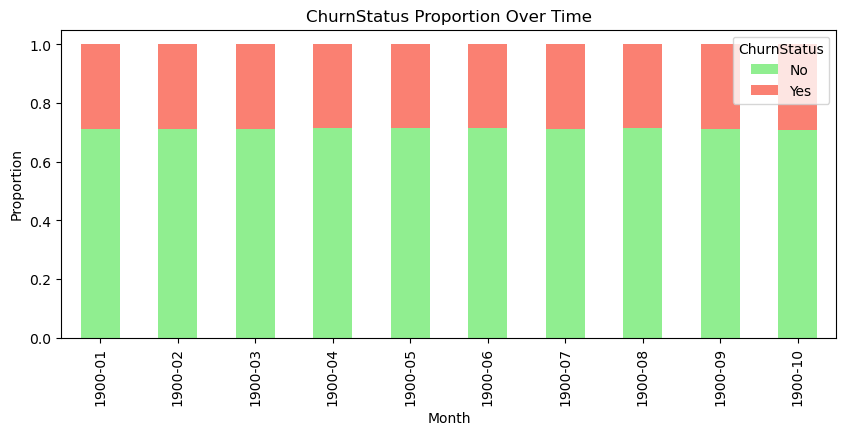

In [33]:
target_prop = train_df.groupby(train_df['Month'].dt.to_period('M'))['ChurnStatus'].value_counts(normalize=True).unstack()
target_prop.plot(kind='bar', stacked=True, figsize=(10,4), color=['lightgreen','salmon'])
plt.title("ChurnStatus Proportion Over Time")
plt.ylabel("Proportion")
plt.xlabel("Month")
plt.legend(title='ChurnStatus')
plt.show()


# 📊 Exploratory Data Analysis (EDA) Summary

## 1️⃣ Dataset Overview
The dataset contains **70,430** customers with a mix of demographic, service, and financial features.

* **Rows:** 70,430
* **Columns:** 45 features
* **Target:** `ChurnStatus` (Binary)

### Feature Composition
| Type | Count |
| :--- | :--- |
| **Numerical** | 17 |
| **Categorical** | 28 |
| **Temporal** | 1 (`Month`) |

### Missing Values & Strategy
| Feature | Missing | Interpretation |
| :--- | :--- | :--- |
| **Offer** | ~48k | No specific promotion applied |
| **InternetType** | ~17k | No internet service subscribed |
| **PrioritySupport** | ~12k | No support plan active |
| **DigitalInvoicing** | ~12k | Paper-based billing |

> **Key Insight:** Missing values are likely **Informative Nulls** (indicating "No Service") rather than random data loss. Feature engineering should treat these as a distinct category.

---

## 2️⃣ Distribution Insights

### Demographic & Tenure
* **Age:** Ranges from 19–80, peaking at **45–50**. The distribution is bell-shaped and stable.
* **Tenure:** Bimodal distribution. We see a high volume of **new customers (1–12 months)** and a solid base of **long-term customers (30–72 months)**.
* **Dependents:** Highly sparse; most customers have 0 dependents.

### Geographic Clustering
* While the data is restricted to California, US, two distinct clusters appear in the **Latitude/Longitude** plots: **Southern California** and **Northern California**. 

### Financial Skewness
* Features like `TotalCharges`, `TotalRevenue`, and `TotalLongDistanceCharges` show a **strong right skew**.
* **Recommendation:** Use `Log Transform` or `RobustScaler` to handle outliers and skewness for model stability.

### Target Balance
* **No Churn:** ~71%
* **Churn:** ~29%
* **Modeling Tip:** Because of this imbalance, the LightGBM parameter `is_unbalance = True` is highly recommended.

---

## 3️⃣ Temporal Analysis (Monitoring for Drift)
By analyzing features across the `Month` column, we can simulate production monitoring:

* **Offer & Contract Stability:** The proportions of different offers and contract types (Month-to-month vs. Yearly) remain consistent.
* **Service Mix:** Fiber Optic remains the dominant internet type throughout the timeline.
* **Target Stability:** The churn rate does not fluctuate significantly over the months recorded in the training set.

---

## 4️⃣ Conclusion: Is Drift Present?
**Short Answer:** ❌ **No major drift detected within the training set.**

* **Evidence:** Feature distributions, category proportions, and target ratios are statistically stable across the temporal dimension.
* **Expectation:** The training data appears **IID** (Independent and Identically Distributed), which aligns with the challenge description.

---

## Train vs Test Distribution Comparison

In [36]:
# Load test dataset
test_df = pd.read_csv("public_data/test.csv")

print("Test dataset shape:", test_df.shape)

# Convert Month to datetime (same as train)
test_df['Month'] = pd.to_datetime(test_df['Month'], format='%d-%b', errors='coerce')

Test dataset shape: (14086, 45)


### Numerical Features

Overlay KDE plots to visually inspect drift.

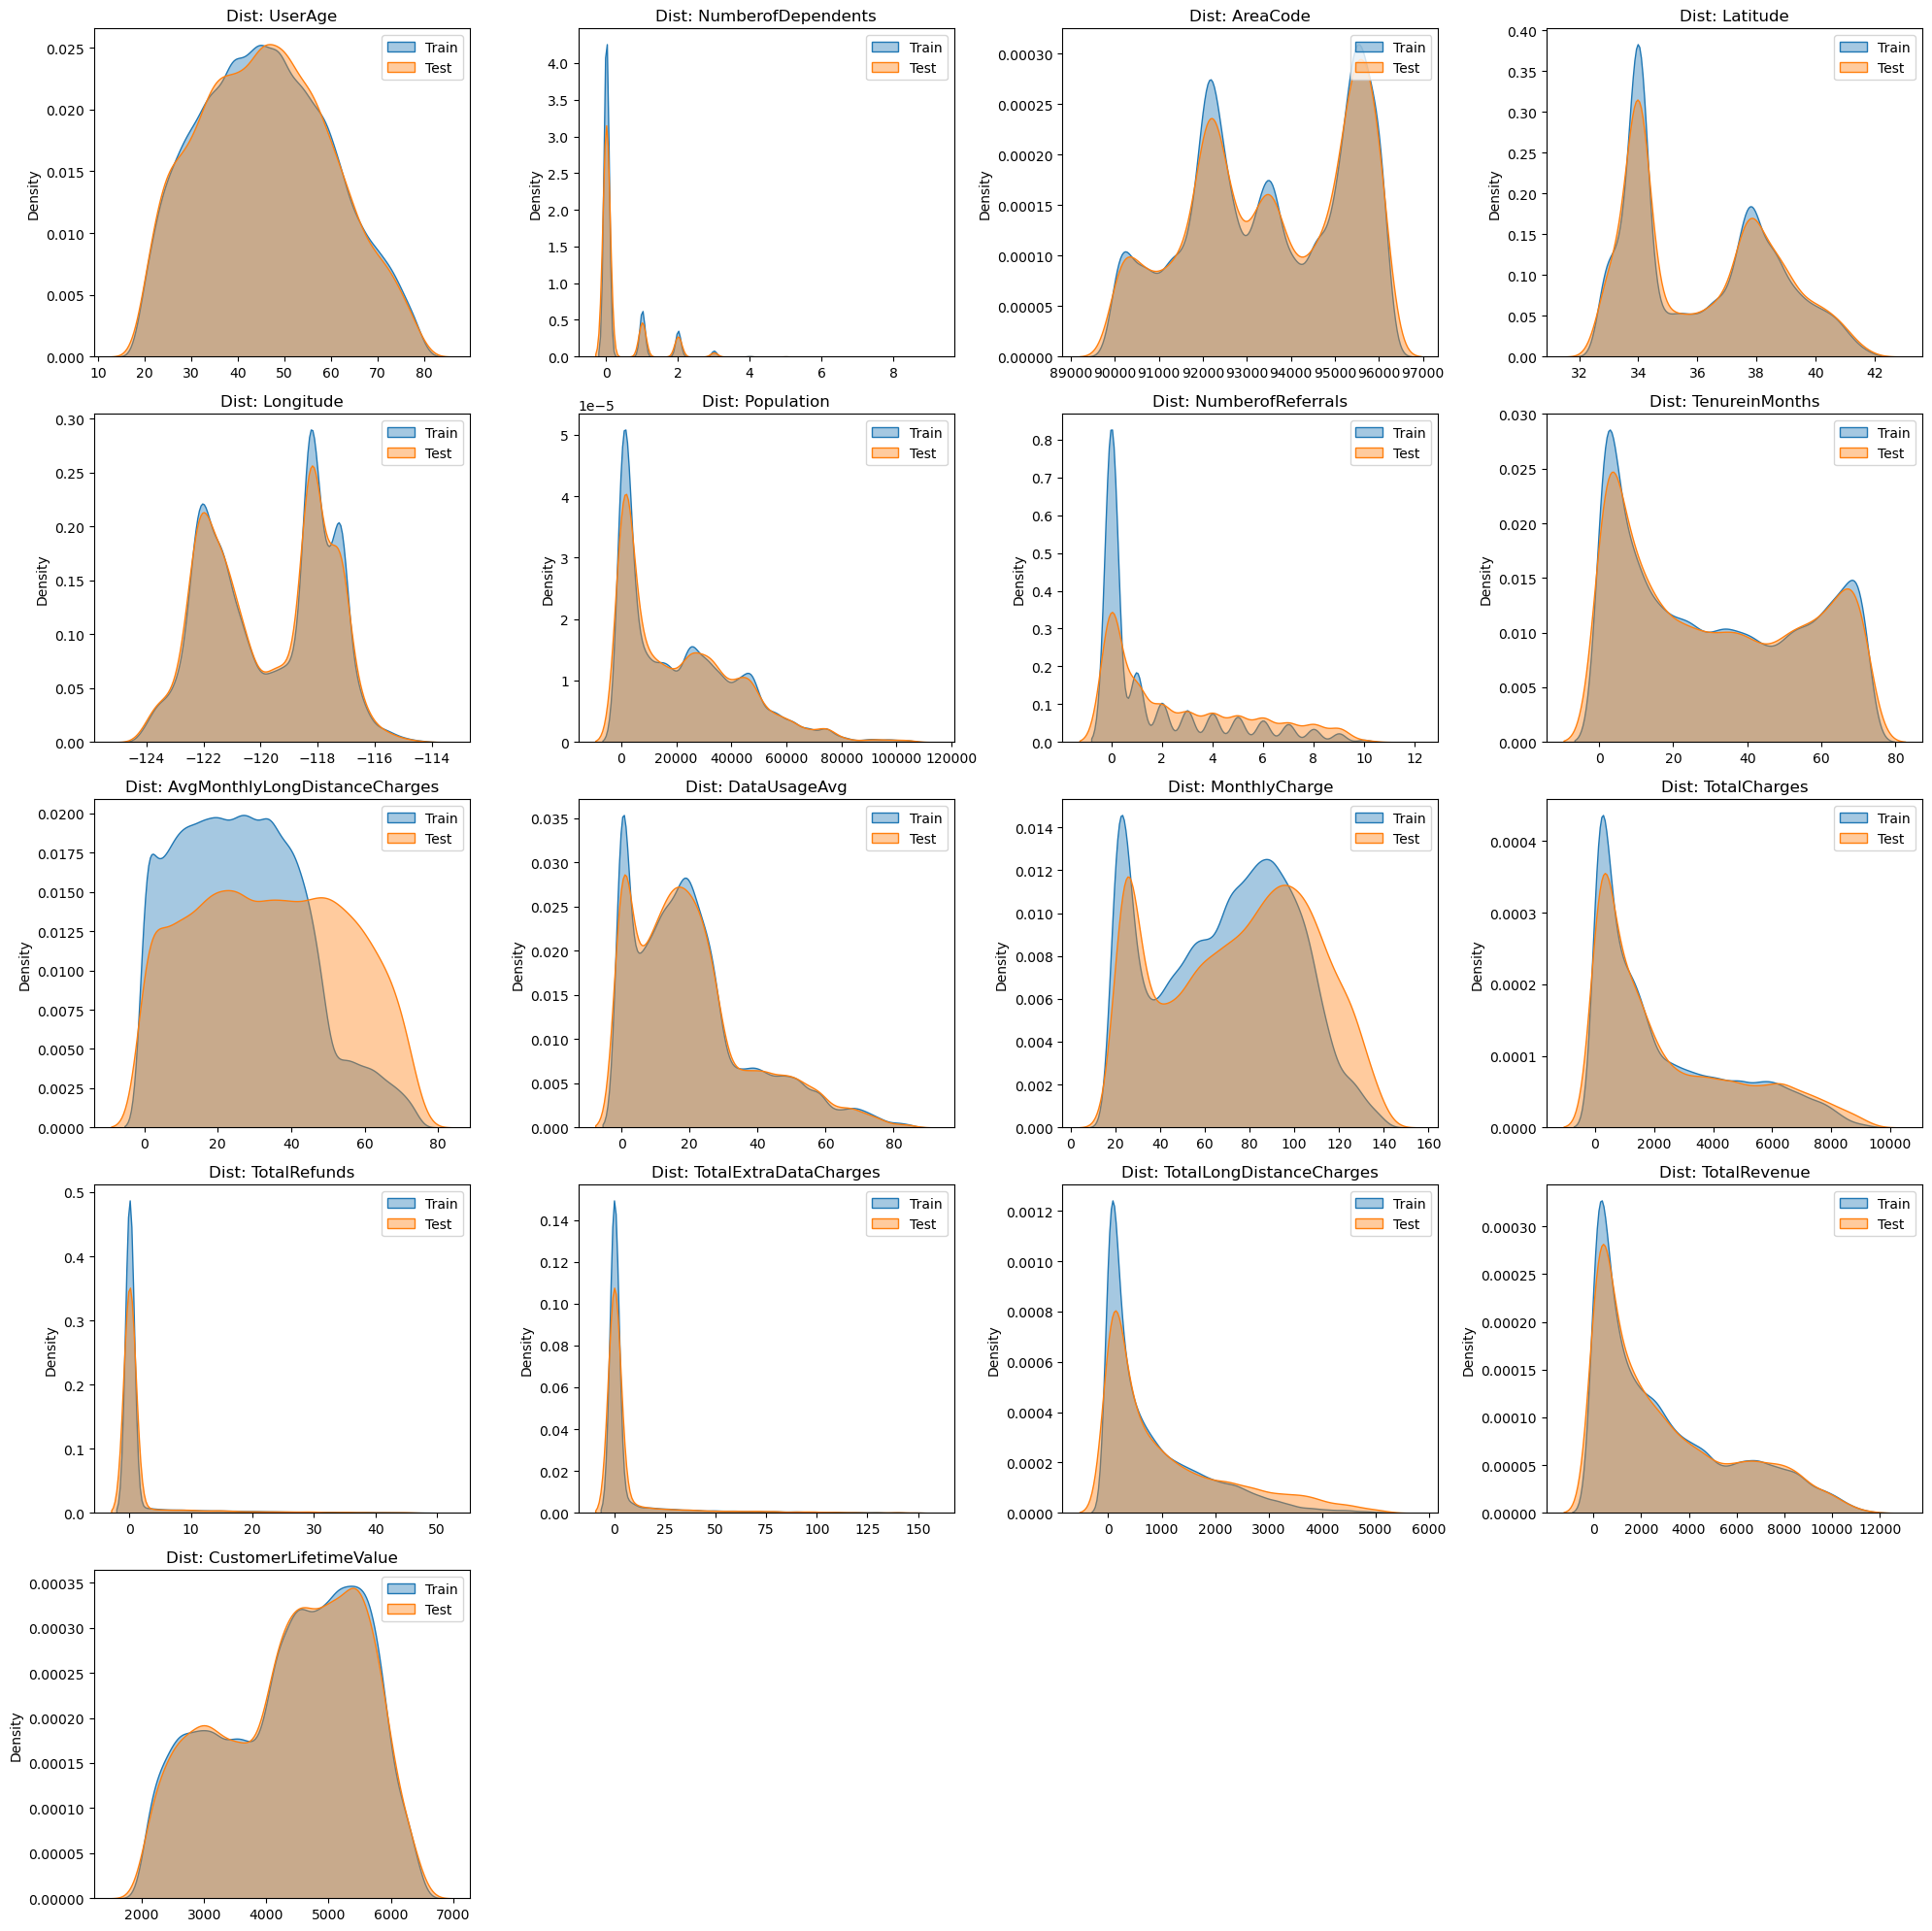

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Prepare your columns
num_cols = [c for c in numerical_features if c != 'CustomerID']

# 2. Define the grid dimensions
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols) # Automatically adjusts based on feature count

# 3. Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten() # Flatten to iterate easily

for i, col in enumerate(num_cols):
    sns.kdeplot(train_df[col], label='Train', fill=True, alpha=0.4, ax=axes[i])
    sns.kdeplot(test_df[col], label='Test', fill=True, alpha=0.4, ax=axes[i])
    
    axes[i].set_title(f"Dist: {col}", fontsize=12)
    axes[i].legend()
    axes[i].set_xlabel("") # Cleaner look

# 4. Remove empty subplots if num_cols < axes available
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Categorical Feature Distribution Comparison

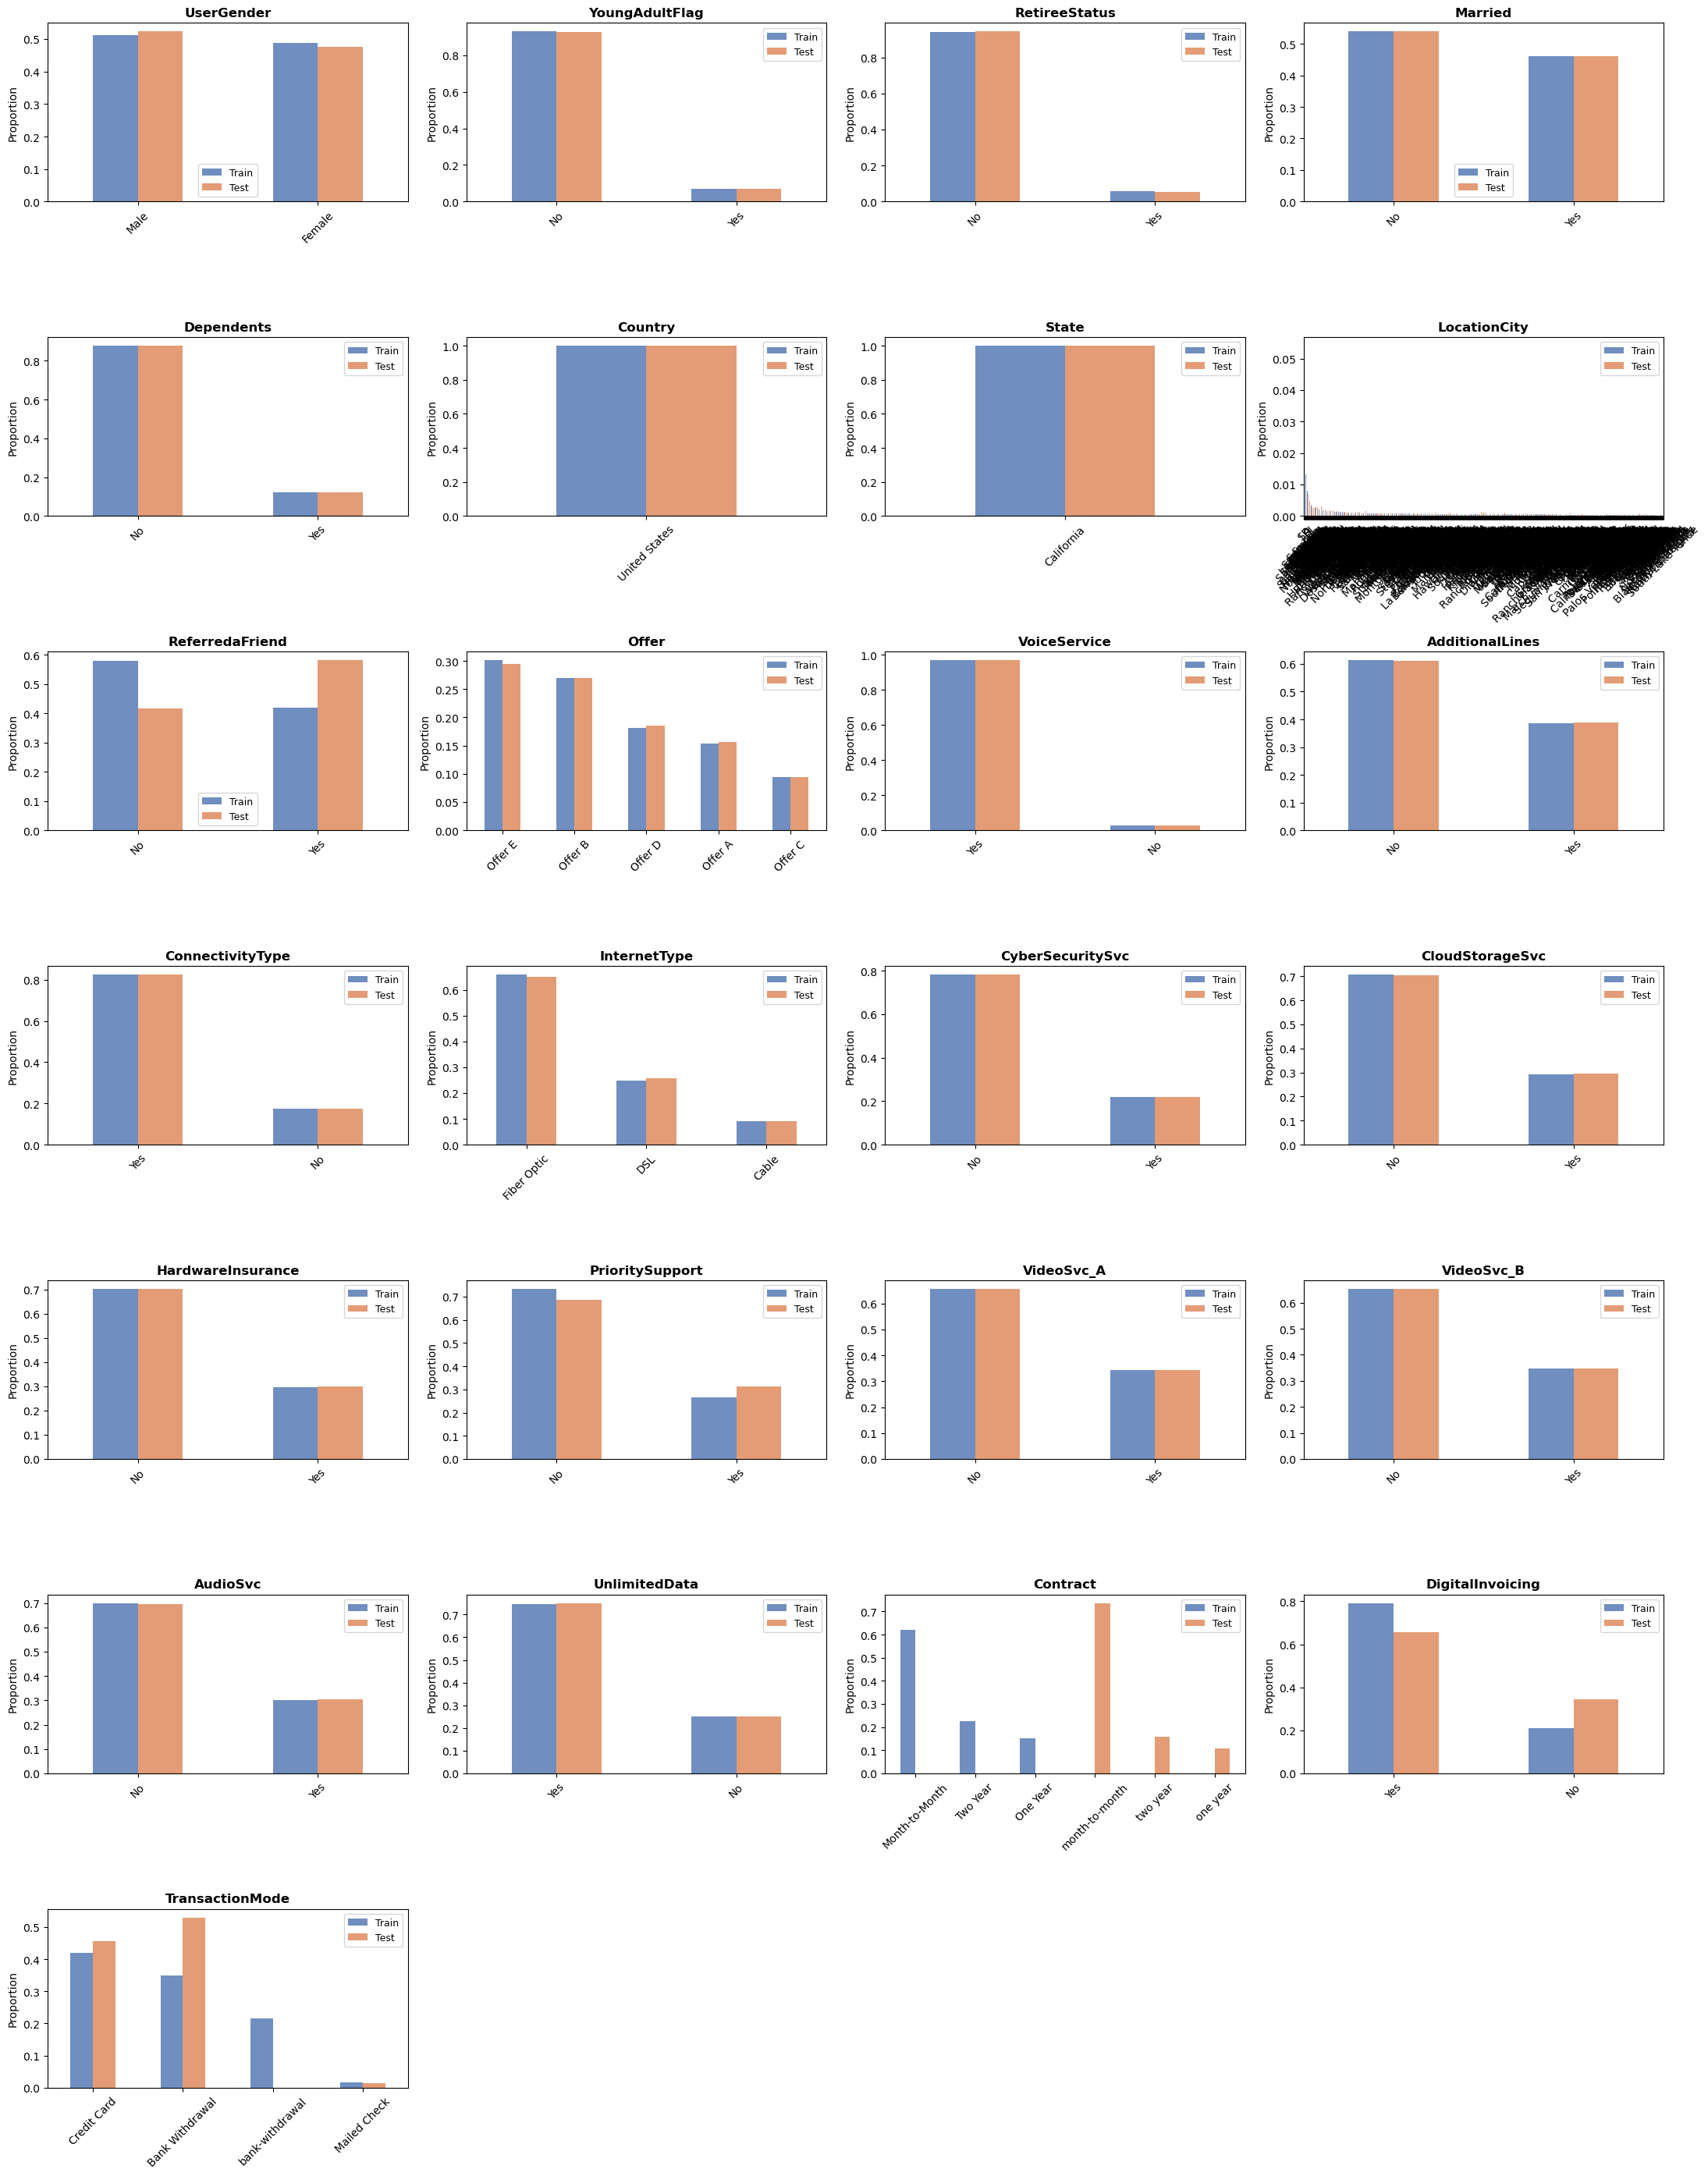

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import math

# 1. Setup columns
cat_cols = [c for c in categorical_features if c not in ['CustomerID', 'ChurnStatus', 'Month']]

# 2. Define grid (5x5 handles 25 plots)
n_cols = 4
n_rows = 7 # Or use math.ceil(len(cat_cols) / n_cols) to show all 28
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i >= len(axes): break  # Safety break if more columns than subplots
    
    # Calculate proportions
    train_prop = train_df[col].value_counts(normalize=True).rename('Train')
    test_prop = test_df[col].value_counts(normalize=True).rename('Test')
    
    # Combine and plot on specific axis
    compare = pd.concat([train_prop, test_prop], axis=1)
    compare.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], alpha=0.8)
    
    axes[i].set_title(f"{col}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=9)

# 3. Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## PSI (Population Stability Index)
PSI is one of the most common drift metrics used in industry.

In [52]:
def calculate_psi(expected, actual, bins=10):

    expected_perc, bin_edges = np.histogram(expected, bins=bins)
    actual_perc, _ = np.histogram(actual, bins=bin_edges)

    expected_perc = expected_perc / len(expected)
    actual_perc = actual_perc / len(actual)

    psi = np.sum((actual_perc - expected_perc) * np.log((actual_perc + 1e-6) / (expected_perc + 1e-6)))

    return psi

In [54]:
psi_results = []

for col in num_cols:
    
    psi = calculate_psi(train_df[col], test_df[col])
    
    psi_results.append({
        "Feature": col,
        "PSI": psi
    })

psi_df = pd.DataFrame(psi_results)

psi_df["Drift_Level"] = pd.cut(
    psi_df["PSI"],
    bins=[-np.inf,0.1,0.25,np.inf],
    labels=["No Drift","Moderate Drift","Severe Drift"]
)

psi_df.sort_values("PSI", ascending=False)

,Feature,PSI,Drift_Level
8,AvgMonthlyLongDistanceCharges,0.271298,Severe Drift
6,NumberofReferrals,0.139402,Moderate Drift
10,MonthlyCharge,0.089913,No Drift
14,TotalLongDistanceCharges,0.074524,No Drift
11,TotalCharges,0.010755,No Drift
0,UserAge,0.001455,No Drift
9,DataUsageAvg,0.001271,No Drift
2,AreaCode,0.001188,No Drift
4,Longitude,0.001015,No Drift
1,NumberofDependents,0.000911,No Drift


### KS Test Drift Detection

The Kolmogorov–Smirnov test checks if two distributions differ.

In [58]:
from scipy.stats import ks_2samp

ks_results = []

for col in num_cols:
    
    stat, p_value = ks_2samp(train_df[col], test_df[col])
    
    ks_results.append({
        "Feature": col,
        "KS Statistic": stat,
        "p_value": p_value,
        "Drift_Detected": p_value < 0.05
    })

ks_df = pd.DataFrame(ks_results)

ks_df.sort_values("KS Statistic", ascending=False)

,Feature,KS Statistic,p_value,Drift_Detected
8,AvgMonthlyLongDistanceCharges,0.206304,0.000000e+00,True
6,NumberofReferrals,0.197288,0.000000e+00,True
10,MonthlyCharge,0.104558,3.467393e-112,True
14,TotalLongDistanceCharges,0.077637,5.534911e-62,True
11,TotalCharges,0.023371,5.308919e-06,True
4,Longitude,0.014823,1.138764e-02,True
3,Latitude,0.011231,1.027289e-01,False
2,AreaCode,0.010422,1.550435e-01,False
15,TotalRevenue,0.006801,6.467606e-01,False
1,NumberofDependents,0.006077,7.764892e-01,False


## Combine PSI + KS into Drift Table

In [61]:
drift_table = psi_df.merge(
    ks_df,
    on="Feature"
)

drift_table.sort_values("PSI", ascending=False)

,Feature,PSI,Drift_Level,KS Statistic,p_value,Drift_Detected
8,AvgMonthlyLongDistanceCharges,0.271298,Severe Drift,0.206304,0.000000e+00,True
6,NumberofReferrals,0.139402,Moderate Drift,0.197288,0.000000e+00,True
10,MonthlyCharge,0.089913,No Drift,0.104558,3.467393e-112,True
14,TotalLongDistanceCharges,0.074524,No Drift,0.077637,5.534911e-62,True
11,TotalCharges,0.010755,No Drift,0.023371,5.308919e-06,True
0,UserAge,0.001455,No Drift,0.005353,8.878315e-01,False
9,DataUsageAvg,0.001271,No Drift,0.005637,8.476831e-01,False
2,AreaCode,0.001188,No Drift,0.010422,1.550435e-01,False
4,Longitude,0.001015,No Drift,0.014823,1.138764e-02,True
1,NumberofDependents,0.000911,No Drift,0.006077,7.764892e-01,False


## Feature vs Churn Analysis

This helps you identify predictive features.

### Numerical Features vs Churn

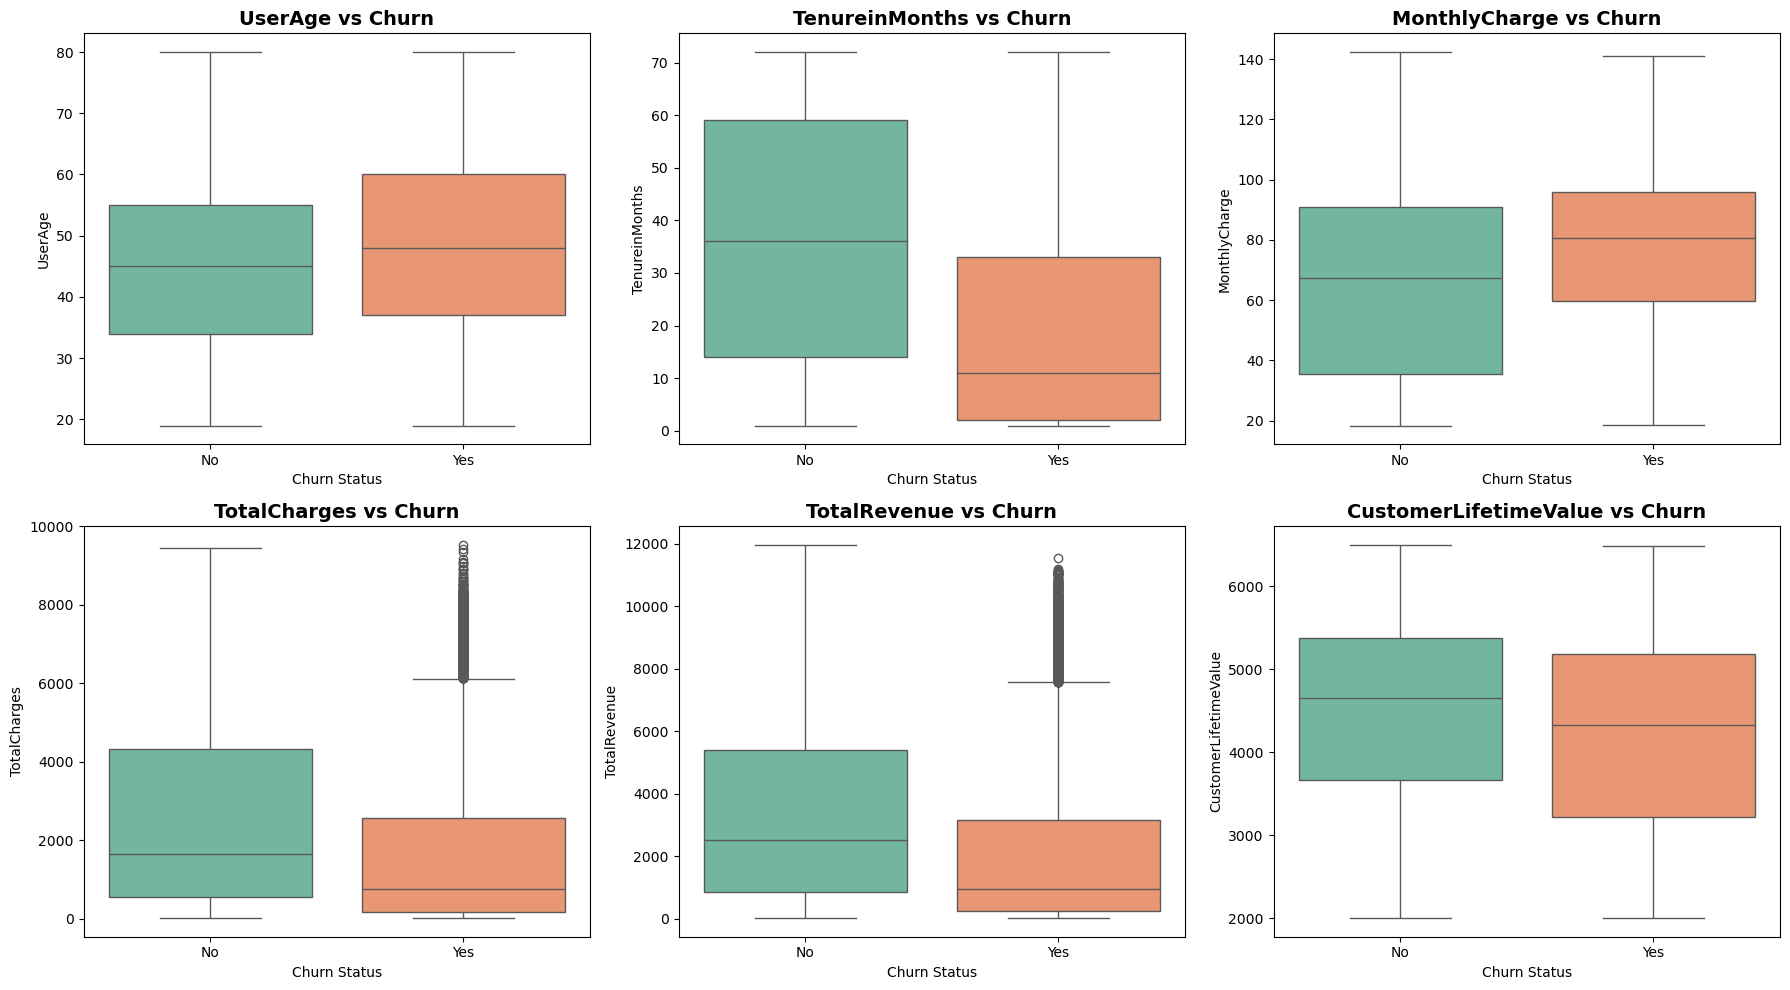

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the columns (as provided)
num_churn_cols = [
    'UserAge',
    'TenureinMonths',
    'MonthlyCharge',
    'TotalCharges',
    'TotalRevenue',
    'CustomerLifetimeValue'
]

# 2. Create a 2x3 grid
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

# 3. Iterate and plot
for i, col in enumerate(num_churn_cols):
    sns.boxplot(
        data=train_df, 
        x='ChurnStatus', 
        y=col, 
        ax=axes[i], 
        palette='Set2' # Distinct colors for Churn vs No Churn
    )
    
    axes[i].set_title(f"{col} vs Churn", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Churn Status", fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

# 4. Final adjustments
plt.tight_layout()
plt.show()

### Categorical Features vs Churn

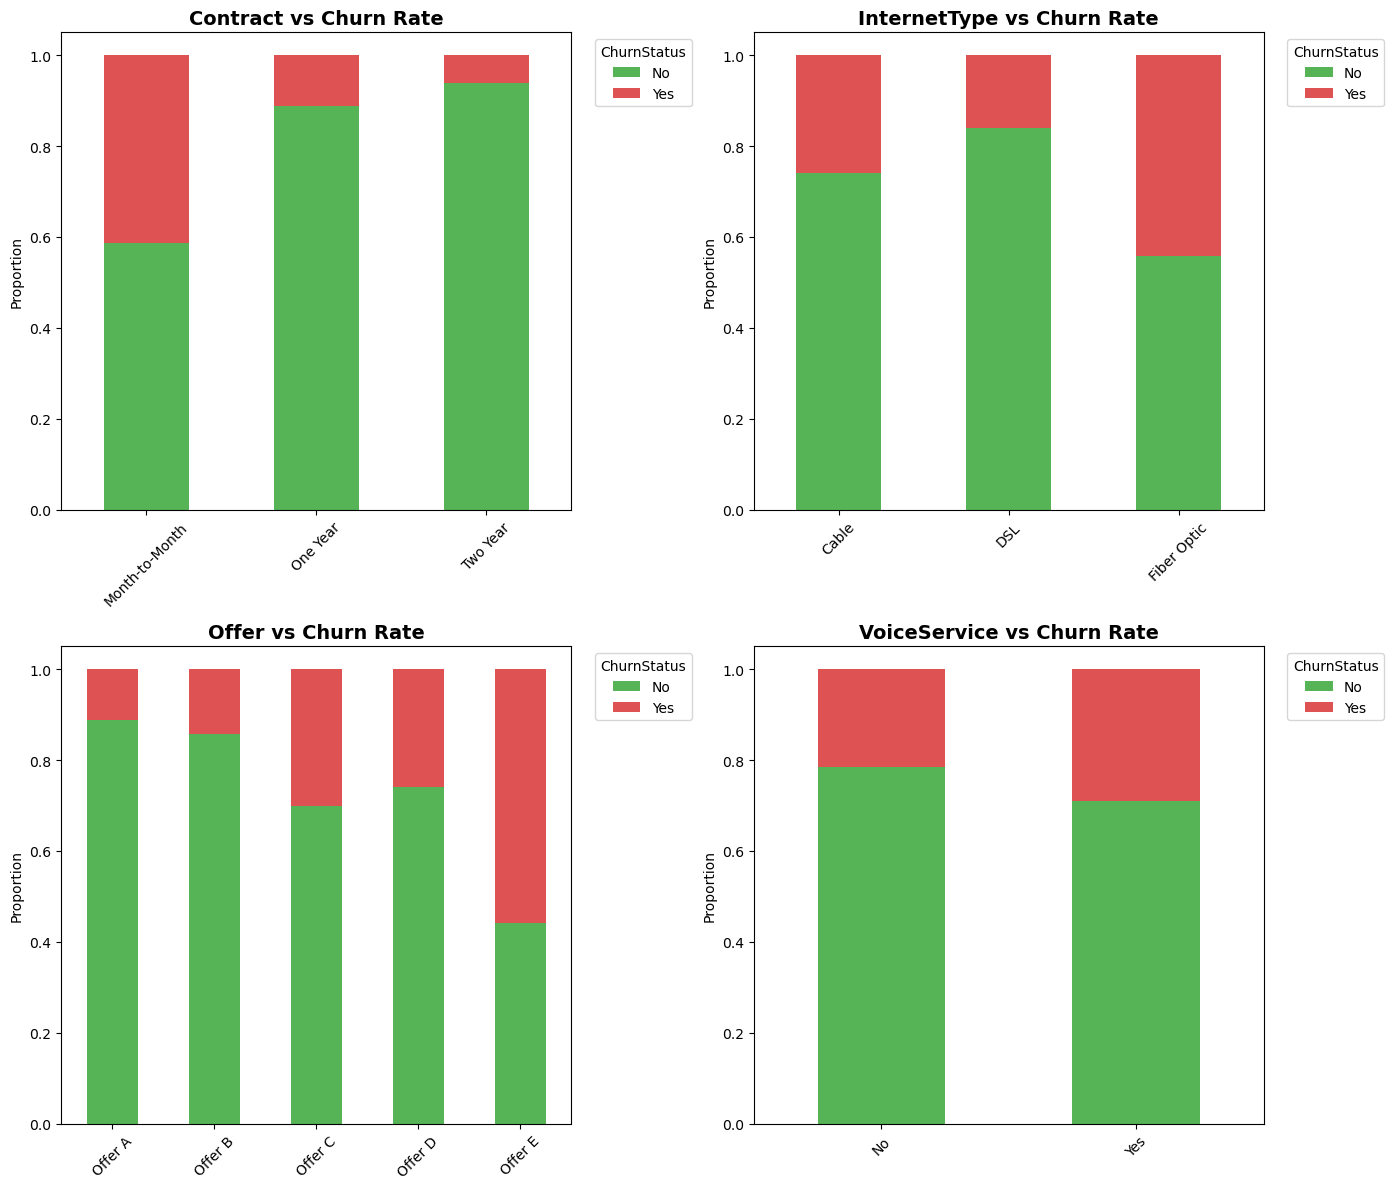

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define the columns
cat_churn_cols = [
    'Contract',
    'InternetType',
    'Offer',
    'VoiceService'
]

# 2. Setup a 2x2 grid
n_rows, n_cols = 2, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 12))
axes = axes.flatten()

# 3. Iterate and plot
for i, col in enumerate(cat_churn_cols):
    # Calculate normalized crosstab (row-wise percentages)
    churn_prop = pd.crosstab(
        train_df[col], 
        train_df['ChurnStatus'], 
        normalize='index'
    )
    
    # Plot to the specific subplot axis
    churn_prop.plot(
        kind='bar', 
        stacked=True, 
        ax=axes[i], 
        color=['#2ca02c', '#d62728'], # Green for No, Red for Yes (Churn)
        alpha=0.8
    )
    
    axes[i].set_title(f"{col} vs Churn Rate", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='ChurnStatus', loc='upper right', bbox_to_anchor=(1.25, 1))

# 4. Final adjustments to prevent overlap
plt.tight_layout()
plt.show()